# Experiment 1 - Stanford Dogs Classification using CNNs

Using the results from experiment 1 - Base CNN, we will now train a model using the same Convolutional Neural Network (CNN) architecture on the Cats & Dogs dataset

Then we will use the same architecture and train a model on the stanfords Dogs dataset (check [cats & dogs notebook](./cnn_experiment_1_stanford_dogs.ipynb)), which is a more challenging dataset with 120 classes of dogs.

## Importing the libraries

These are most of the import needed for this experiment. We will import some more libraries if needed during the experiment.

In [4]:
import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


## Generating the dataset

Now we can generate and load the dataset using ImageLoader and DataLoader from pytorch.

In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

def load_from_directory(
    root_dir: str,
    batch_size: int = 32,
    val_split: float = 0.2,
    train_transforms: transforms.Compose = None,
    val_transforms: transforms.Compose = None,
):
    # Load the dataset twice to handle different transforms
    train_full_dataset = datasets.ImageFolder(root=root_dir, transform=train_transforms)
    val_full_dataset = datasets.ImageFolder(root=root_dir, transform=val_transforms)

    # Calculate exact sizes for 80/20 split
    total_size = len(train_full_dataset)
    validation_size = int(val_split * total_size)
    train_size = total_size - validation_size

    # Randomly generate indices
    generator = torch.Generator().manual_seed(42)
    indices = torch.randperm(total_size, generator=generator).tolist()

    # Slice indices into Train and Val
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # Create Subsets
    train_dataset = Subset(train_full_dataset, train_indices)
    validation_dataset = Subset(val_full_dataset, val_indices)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, validation_loader, train_full_dataset.classes

# Basic data transformation
basic_transform = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Pixel values between -1 and 1
])

train_loader, validation_loader, class_names = load_from_directory(
    "/kaggle/input/datasets/rahulchander/stanford-dogs-cnn-experiment/Images/",
    train_transforms=basic_transform,
    val_transforms=basic_transform,
)

print(f"{len(class_names)} Classes: {class_names}")
print(f"Number of batches in train loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(validation_loader)}")

120 Classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n0209443

#### Visualize the data

Same as before we have to visualize the data to have a better understanding of the dataset and to check if the data is loaded correctly.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8745098..0.7254902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..1.0].


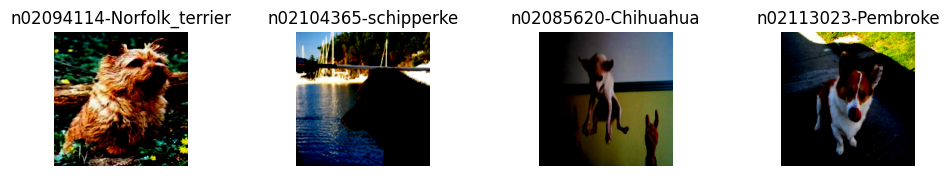

In [14]:
def visualize_batch(loader: DataLoader, class_names: list) -> None:
    images, labels = next(iter(loader))
    images = images.numpy().transpose((0, 2, 3, 1))

    plt.figure(figsize=(12, 8))
    for i in range(4):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

visualize_batch(train_loader, class_names)

Then we have plots of curves functions.

In [15]:
def plot_loss(train_losses: list, val_losses: list) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend() # This enables the labels
    plt.show()

def plot_accuracy(train_accuracies: list, val_accuracies: list) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend() # Added this to show the legend
    plt.show()

#### Data Augmentation

We will use the same data augmentation techniques as before, but we will also add some more techniques to see if it improves the performance of the model.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8901961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.67058825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9607843].


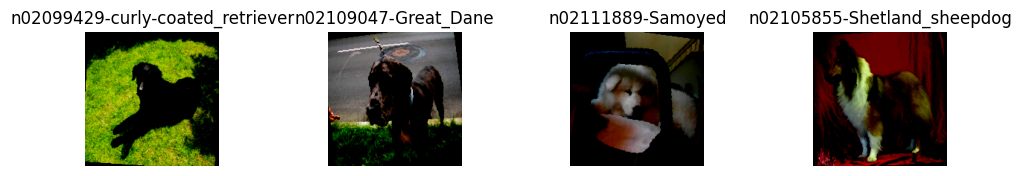

In [16]:
data_augmentation_transforms = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.RandomRotation(10), # 10 degrees rotation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Pixel values between -1 and 1
])

# Loading again with the new data augmentation transforms
train_loader, validation_loader, class_names = load_from_directory(
    "/kaggle/input/datasets/rahulchander/stanford-dogs-cnn-experiment/Images/",
    train_transforms=data_augmentation_transforms,
    val_transforms=basic_transform,
)
visualize_batch(train_loader, class_names)

## CNN Architecture

We just copy the same architecture from the previous experiment and train it on the new dataset.

In [17]:
## Understanding the architecture of the model: Separable Convolution and Residual Connections
class SeparableConv2d(nn.Module):
    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 3,
        padding: int = 1,
    ):
        super().__init__()

        # Depthwise: one filter bank per input channel (no cross-channel mixing)
        self.depthwise = nn.Conv2d(
            in_ch,
            in_ch,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_ch, # No mixing of channels, each channel is convolved separately
            bias=False,
        )

        # Pointwise: 1x1 conv to mix channels and set output channels
        self.pointwise = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class ResidualSeparableConv2dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(in_ch=in_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.ReLU(),
            SeparableConv2d(in_ch=out_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Project residual to match both spatial size and channels
        self.proj_res = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            stride=2,
            padding=0,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x) + self.proj_res(x)


class CatsAndDogsCNN(nn.Module):
    def __init__(self, num_classes: int = 2, in_channels: int = 3):
        super().__init__()

        # Entry block
        self.entry_block = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Residual blocks for channel progression 128 -> 256 -> 512 -> 728
        self.blocks = nn.Sequential(
            ResidualSeparableConv2dBlock(in_ch=128, out_ch=256),
            ResidualSeparableConv2dBlock(in_ch=256, out_ch=512),
            ResidualSeparableConv2dBlock(in_ch=512, out_ch=728),
        )

        out_units = 1 if num_classes == 2 else num_classes

        # Final layers
        self.final_layers = nn.Sequential(
            SeparableConv2d(in_ch=728, out_ch=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(1024, out_units), # logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # No scaling here because it is done by ToTensor() transform

        x = self.entry_block(x)
        x = self.blocks(x)
        x = self.final_layers(x)
        return x


model = CatsAndDogsCNN(num_classes=len(class_names)).to(device)

## Train the model

We init the hyperparameters and the loss function and the optimizer and then we train the model for 25 epochs. Same as the other model we had.

However, we use CrossEntropyLoss instead of BCEWithLogitsLoss because we have more than 2 classes in the dataset.

In [18]:
EPOCHS = 30
LR = 1e-4

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [19]:
from typing import List, Tuple
from tqdm import tqdm

def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float]:
    model.train()
    total_loss = 0
    total_accuracy = 0

    for images, labels in tqdm(dataloader):
        images: torch.Tensor = images.to(device)
        labels: torch.Tensor = labels.type(torch.LongTensor).to(device)

        # Forward pass
        outputs: torch.Tensor = model(images)
        loss: torch.Tensor = loss_fn(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluate accuracy
        if outputs.shape[1] == 1:
            # Squeeze to add a dimension
            preds = (torch.sigmoid(outputs.squeeze()) >= 0.5).long()
            total_accuracy += (preds == labels).sum().item()
        else:
            _, preds = torch.max(outputs, 1)
            total_accuracy += (preds == labels).sum().item()

        total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(dataloader.dataset)
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, avg_accuracy


def validate_model(
    model: nn.Module,
    val_dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    model.eval()
    total_loss = 0
    total_accuracy = 0

    with torch.inference_mode():
        for images, labels in tqdm(val_dataloader):
            images: torch.Tensor = images.to(device)
            labels: torch.Tensor = labels.type(torch.LongTensor).to(device)

            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = loss_fn(outputs, labels)

            # Evaluate accuracy
            if outputs.shape[1] == 1:
                # Squeeze to add a dimension
                preds = (torch.sigmoid(outputs.squeeze()) >= 0.5).long()
                total_accuracy += (preds == labels).sum().item()
            else:
                _, preds = torch.max(outputs, 1)
                total_accuracy += (preds == labels).sum().item()

            total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(val_dataloader.dataset)
    avg_loss = total_loss / len(val_dataloader.dataset)
    return avg_loss, avg_accuracy


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 25,
    model_save_path: str = "best_model_base_stanford_dogs.pth",
) -> Tuple[List[float], List[float], List[float], List[float]]:
    # Track the losses
    train_losses = []
    val_losses = []

    # Track the accuracy
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')

    for epoch in tqdm(range(epochs)):
        print("\nTraining pass:")
        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        print("\nValidation pass:")
        val_loss, val_accuracy = validate_model(model, validation_loader, loss_fn, device)

        # Track the accuracies
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Track the losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

        # Model Checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save the model weights
            torch.save(model.state_dict(), model_save_path)
            print(f"New best validation loss! Model saved to '{model_save_path}'")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
# Restart the loading of the data to reset the iterator
train_loader, validation_loader, class_names = load_from_directory(
    "/kaggle/input/datasets/rahulchander/stanford-dogs-cnn-experiment/Images/",
    train_transforms=data_augmentation_transforms,
    val_transforms=basic_transform,
    batch_size=64
)

model = torch.nn.DataParallel(model, device_ids = [0,1]).to(device)

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
)

  0%|          | 0/30 [00:00<?, ?it/s]


Training pass:



100%|██████████| 258/258 [02:37<00:00,  1.64it/s]



Validation pass:



  3%|▎         | 1/30 [03:00<1:27:17, 180.59s/it]

...

Epoch 29/30 - Train Loss: 0.8464 - Val Loss: 2.0216

Training pass:



100%|██████████| 258/258 [02:33<00:00,  1.69it/s]



Validation pass:



100%|██████████| 30/30 [1:27:11<00:00, 174.40s/it]

Epoch 30/30 - Train Loss: 0.7968 - Val Loss: 1.9363
New best validation loss! Model saved to 'best_model_base_stanford_dogs.pth'


#### Plotting the curves

After training the model, we will plot the training and validation loss and accuracy curves to see how the model is performing during training.

Plotting the loss:


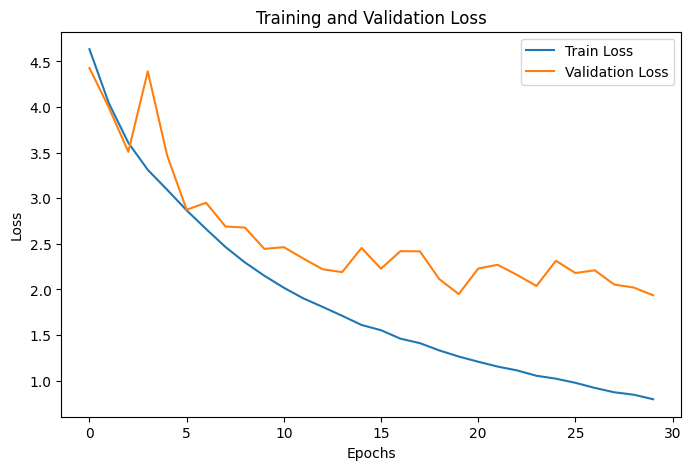


Plotting the accuracy


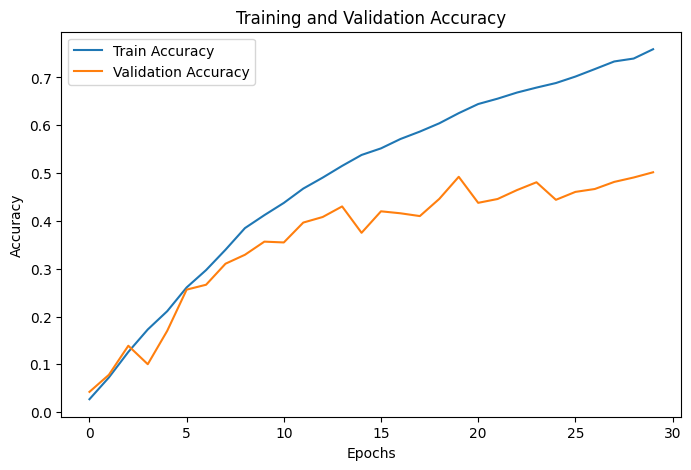

In [21]:
print("Plotting the loss:")
plot_loss(train_losses, val_losses)

print()
print("Plotting the accuracy")
plot_accuracy(train_accuracies, val_accuracies)

### Run inference on new data

Now we can run our model on real data

In [23]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
) -> float:
    model.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in tqdm(test_loader):
            images = images.to(device)
            labels: torch.Tensor = labels.type(torch.LongTensor).to(device)

            outputs = model(images).squeeze()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    return accuracy

evaluate_model(model, validation_loader, device)

100%|██████████| 65/65 [00:21<00:00,  3.05it/s]

Test Accuracy: 50.17%


0.5017006802721088

Testing on a single image of a dog from the internet to see if our model can correctly classify it.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..1.0].


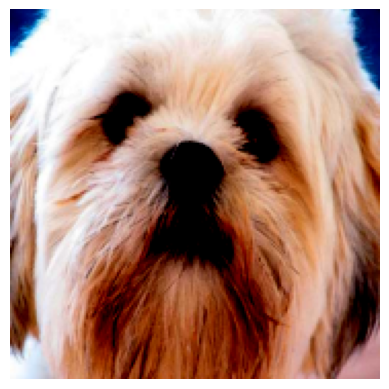

n02098413-Lhasa vs n02098413-Lhasa


In [24]:
def predict_one(model: nn.Module, image: torch.Tensor, label: torch.Tensor, device: torch.device) -> str:
    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.inference_mode():
        output = torch.sigmoid(model(image).squeeze())

    return f"{class_names[output.argmax()]} vs {class_names[label]}"

def display_image(image: torch.Tensor) -> None:
    image = image.numpy().transpose((1, 2, 0))

    plt.imshow(image)
    plt.axis("off")
    plt.show()

data = next(iter(validation_loader))

image = data[0][0]
label = data[1][0]

display_image(image)
print(predict_one(model, image, label, device))